<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 59 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Survey Demographics: the Chi-Square Test 📋</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Are two categorical variables related, or independent? The chi-square test of independence compares the counts we observe against the counts we would expect by chance. Subscription tier strongly drives satisfaction, but region does not.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/ab_survey_demographics.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"ab_survey_demographics.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 4)


,respondent_id,demographic_region,subscription_tier,satisfaction_level
0,RESP_50000,EU,Premium,High
1,RESP_50001,APAC,Free,Low
2,RESP_50002,NaN,Premium,High
3,RESP_50003,EU,Free,Medium
4,RESP_50004,EU,Free,Low


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · THE CONTINGENCY TABLE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Cross-tabulate tier against satisfaction</div>
<div style="color:#4a5578;margin-top:6px">The chi-square test works on counts, not averages. We cross-tabulate every respondent's subscription_tier against their satisfaction_level to get a contingency table, the raw material of the test.</div>
</div>

In [2]:
ct = pd.crosstab(df.subscription_tier, df.satisfaction_level)
ct = ct[["Low","Medium","High"]]   # order the satisfaction levels
print("observed counts:"); print(ct)
print(f"\ntotal respondents tabulated: {ct.values.sum()}")

observed counts:
satisfaction_level  Low  Medium  High
subscription_tier                    
Free                202     198   101
Premium              17      53   130
Standard             60     157    82

total respondents tabulated: 1000


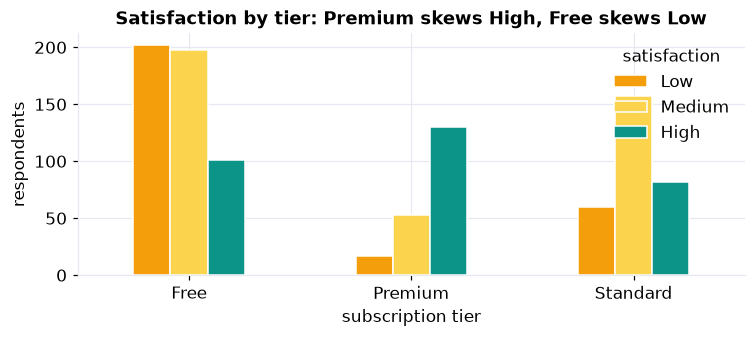

In [3]:
fig,ax=plt.subplots(figsize=(7,3.2))
ct.plot(kind="bar",ax=ax,color=["#f59e0b","#fcd34d","#0d9488"],edgecolor="white")
ax.set_xlabel("subscription tier"); ax.set_ylabel("respondents"); ax.set_title("Satisfaction by tier: Premium skews High, Free skews Low")
ax.tick_params(axis="x",rotation=0); ax.legend(title="satisfaction")
plt.tight_layout(); plt.show()

Eyeballing the bars, **Premium** users pile up in *High* satisfaction while **Free** users pile up in *Low*. The pattern looks real, but is it more than sampling noise? The chi-square test answers exactly that.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · OBSERVED vs EXPECTED</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What would independence look like?</div>
<div style="color:#4a5578;margin-top:6px">If tier and satisfaction were independent, each cell's count would be (row total times column total) / grand total. Chi-square sums the squared gaps between observed and expected, scaled by expected.</div>
</div>

In [4]:
chi2, pval, dof, expected = stats.chi2_contingency(ct)
exp = pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1)
print("expected counts under independence:"); print(exp)
print(f"\nchi-square = {chi2:.2f},  df = (r-1)(c-1) = {dof},  p-value = {pval:.2e}")
cramers_v = np.sqrt(chi2/(ct.values.sum()*(min(ct.shape)-1)))
print(f"Cramers V (effect size) = {cramers_v:.3f}")
print("-> reject independence: tier and satisfaction ARE related" if pval<0.05 else "-> independent")

expected counts under independence:
satisfaction_level    Low  Medium   High
subscription_tier                       
Free                139.8   204.4  156.8
Premium              55.8    81.6   62.6
Standard             83.4   122.0   93.6

chi-square = 175.39,  df = (r-1)(c-1) = 4,  p-value = 7.28e-37
Cramers V (effect size) = 0.296
-> reject independence: tier and satisfaction ARE related


The gaps are stark: **Premium / Low** has only **17** respondents where independence predicts **56**, and **Free / Low** has **202** where independence predicts **140**. The chi-square statistic of **175** with df = 4 gives p &#8776; 10<sup>&#8722;37</sup>, so satisfaction is overwhelmingly tied to tier. Cramer's V &#8776; **0.30** says the association is moderate in strength, not just statistically detectable.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · THE CONTROL: REGION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A variable that IS independent</div>
<div style="color:#4a5578;margin-top:6px">Significance is not automatic, the test can also confirm independence. We run the same test on demographic_region against satisfaction, where we expect no real relationship.</div>
</div>

In [5]:
ct_r = pd.crosstab(df.demographic_region, df.satisfaction_level)[["Low","Medium","High"]]
chi2r, pvalr, dofr, _ = stats.chi2_contingency(ct_r)
print("region vs satisfaction:"); print(ct_r)
print(f"\nchi-square = {chi2r:.2f},  df = {dofr},  p-value = {pvalr:.3f}")
print("-> reject independence" if pvalr<0.05 else "-> fail to reject: region and satisfaction look INDEPENDENT")

region vs satisfaction:
satisfaction_level  Low  Medium  High
demographic_region                   
APAC                 73     102    75
EU                   69     103    91
LATAM                72     109    63

chi-square = 4.80,  df = 4,  p-value = 0.309
-> fail to reject: region and satisfaction look INDEPENDENT


Here the chi-square is a tiny **4.8** with p &#8776; **0.31**, far above 0.05, so we *fail to reject* independence: satisfaction does not vary by region. This is the discipline of the test, it flags the real association (tier) and clears the spurious one (region), instead of finding a pattern in everything.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">The chi-square test of independence compares observed cell counts against the counts expected if two categorical variables were unrelated. Subscription tier and satisfaction are strongly dependent (&#967;&#178; = 175, p &#8776; 10<sup>&#8722;37</sup>, Cramer's V &#8776; 0.30); region and satisfaction are independent (&#967;&#178; = 4.8, p &#8776; 0.31). Counts, not means, and a chi-square that grows with every gap between what we see and what chance predicts.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>